# Задание 4

### Бганцова Полина Б06-305

## **Часть 1 - Сборка с Velvet**

Для сборки использованы k‑mer 21, 31, 41, 51 с шагом ~10, чтобы оценить влияние длины k‑mer на качество сборки

SLURM-скрипт для запуска Velvet

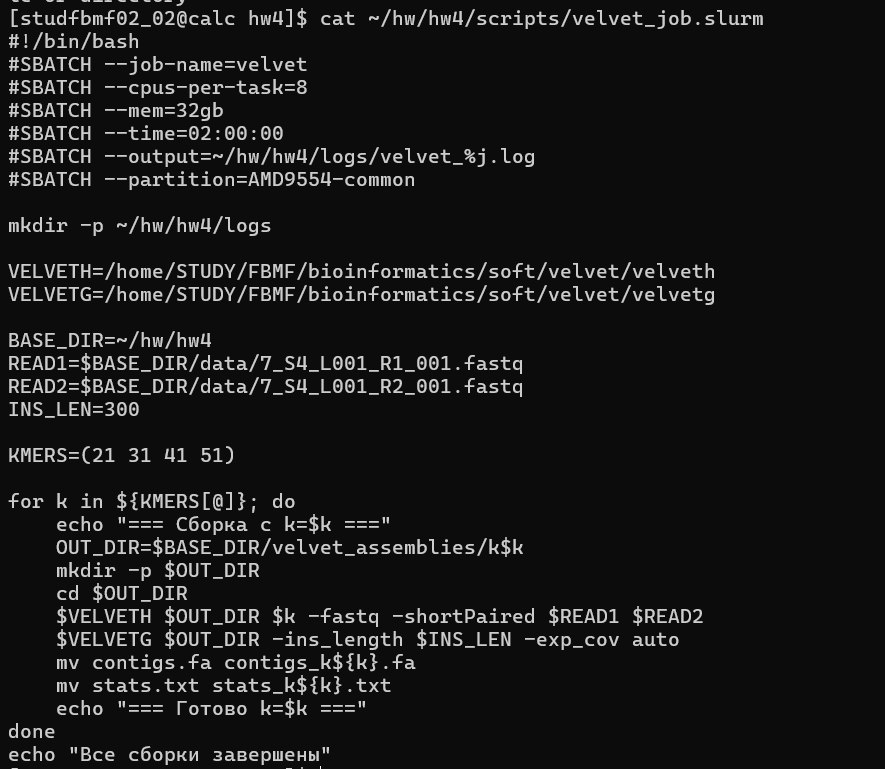

Скриншот вывода команды

`ls -la --time=ctime ~/hw/hw4/velvet_assemblies/`

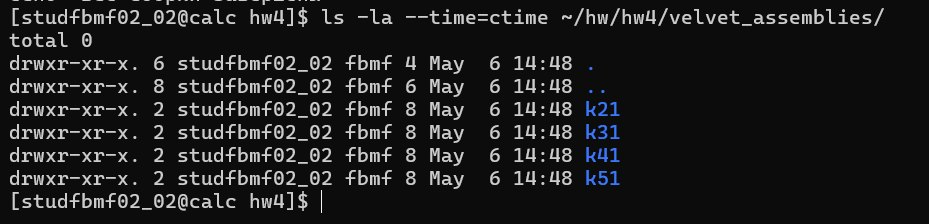



СОдержимое папок на примере к21, к31


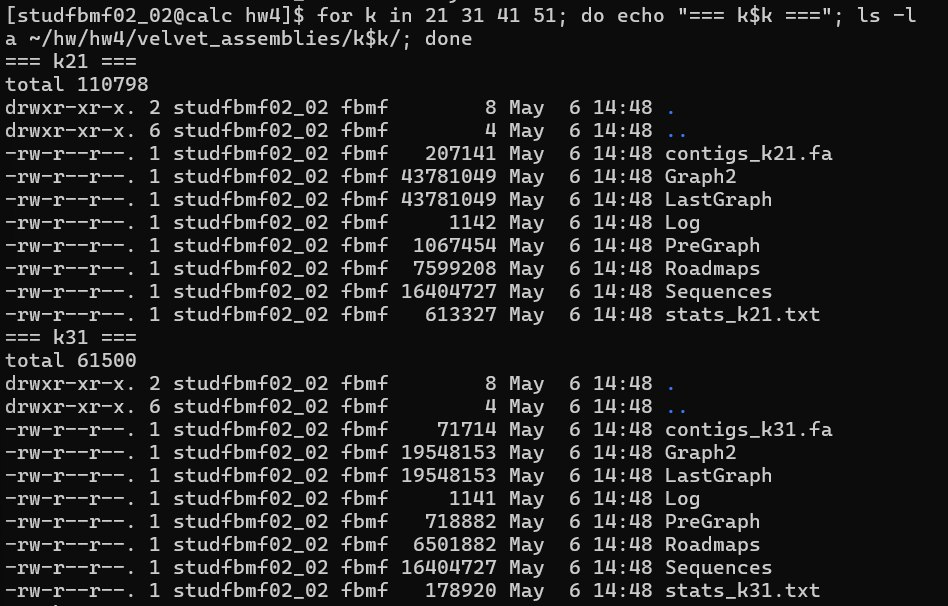

## **Часть 2  — Сравнение сборок**

 SLURM-скрипт, которым запускали QUAST для всех сборок

 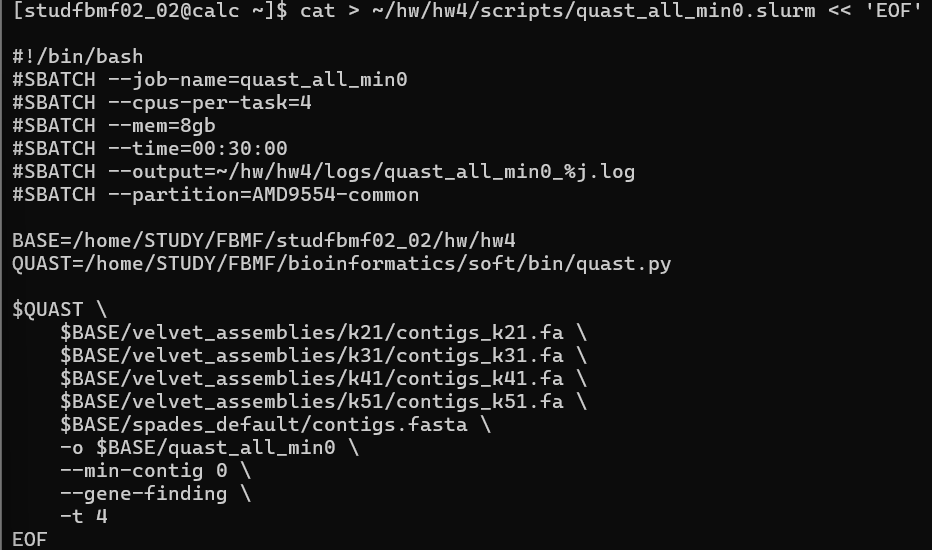

Сводная таблица QUAST

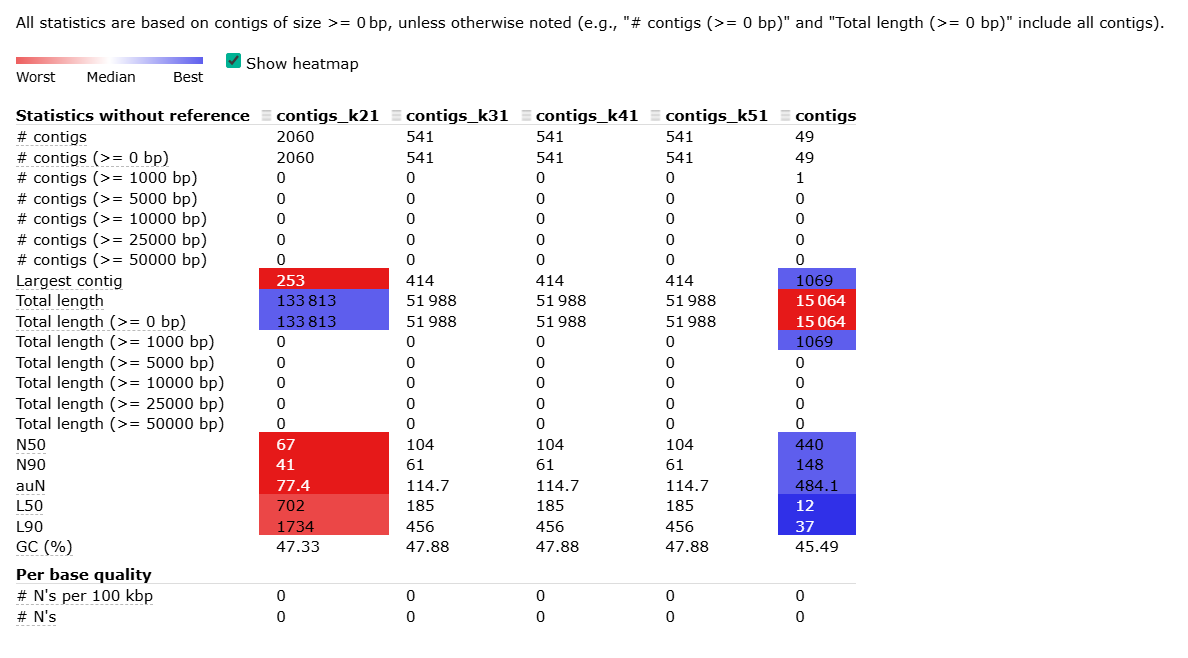

**Анализ таблицы**

- SPAdes собирает **в 10–40 раз меньше контигов** при **в 4–6 раз более высоком N50**.
- Самый длинный контиг SPAdes (1069) более чем в 2,5 раза длиннее лучшего контига Velvet (414).
- Общая длина SPAdes почти в 10 раз меньше, чем у Velvet k21, но это связано с тем, что Velvet генерирует множество очень коротких фрагментов, которые искусственно увеличивают суммарную длину, не улучшая качества сборки.

**Объяснение причин**
- **SPAdes** использует множественные k-меры, итеративную коррекцию ошибок чтения и специальные модули для работы с парными концами.

- **Velvet** требует тщательной подгонки одного k-мера и предварительной очистки данных. На наших данных он дал множество очень коротких контигов (длина большинства < 500 п.н.), что делает сборку малопригодной для дальнейшего анализа (аннотации, поиска генов). Даже оптимизация k-мера (31–51) не позволила получить контиги длиннее 414 п.н.

- Высокий N50 и малое число контигов SPAdes означают, что геном собран в меньшее число длинных фрагментов, что критически важно для последующего картирования генов и поиска структурных вариаций. Velvet же выдаёт «облако» коротких обрывков, с которыми работать крайне неудобно.

**Вывод**

 SPAdes значительно превосходит Velvet по всем метрикам качества сборки, Velvet не смог собрать ни одного контига длиннее 500 п.н. (при том что QUAST пришлось запускать с `--min-contig 0`, чтобы вообще увидеть его сборки). Для данных коротких прочтений SPAdes является единственным пригодным ассемблером благодаря встроенной коррекции ошибок и адаптивному выбору k-меров.


## Часть 3 — Улучшение сборки

**Подобранные параметры**

- SPAdes: добавлен флаг `--isolate`, который оптимизирует алгоритм для чистых бактериальных изолятов (убирает метагеномные настройки, что часто улучшает непрерывность контигов).

- Velvet: добавлен параметр `-cov_cutoff 10`, который отсекает рёбра графа с покрытием ниже этого порога, удаляя ошибочные контиги и потенциально увеличивая N50.

Скрипт для улучшенного Velvet

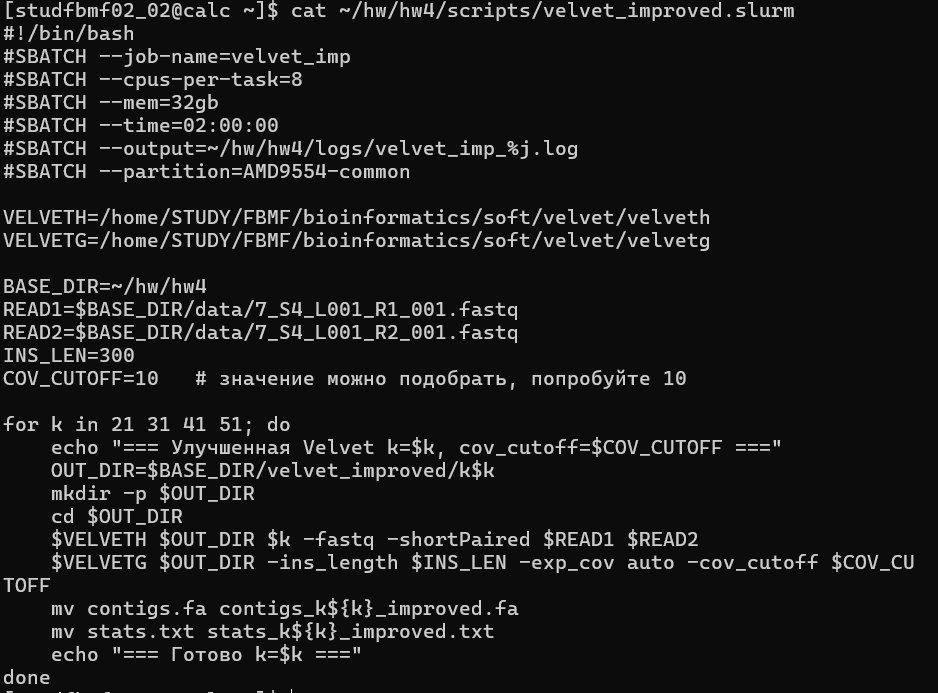

Скрипт для улучшенного SPAdes

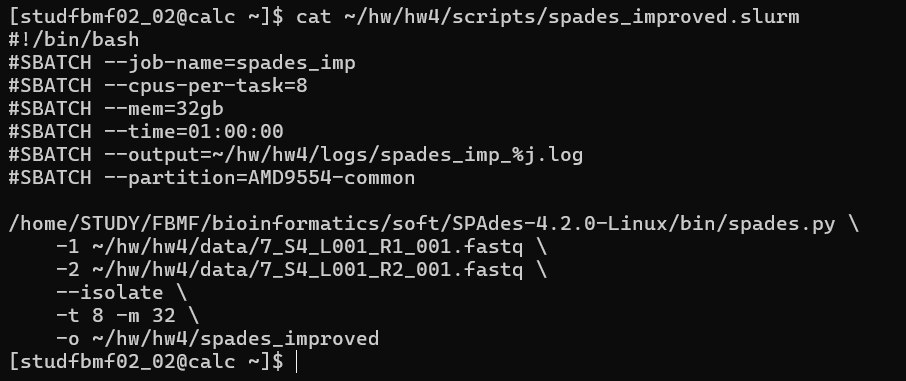

Скрипт для QUAST с 4 сборками

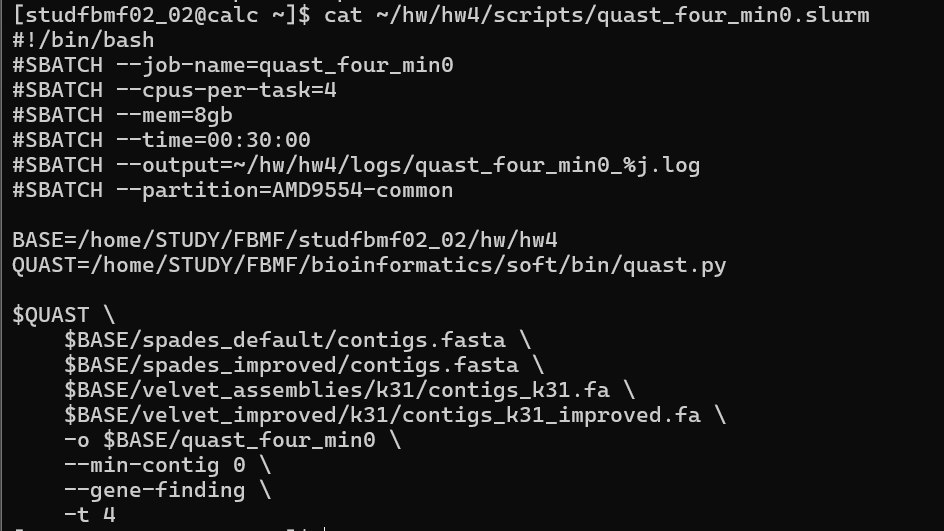

Сводная таблица - сравнение 4ёх сборок

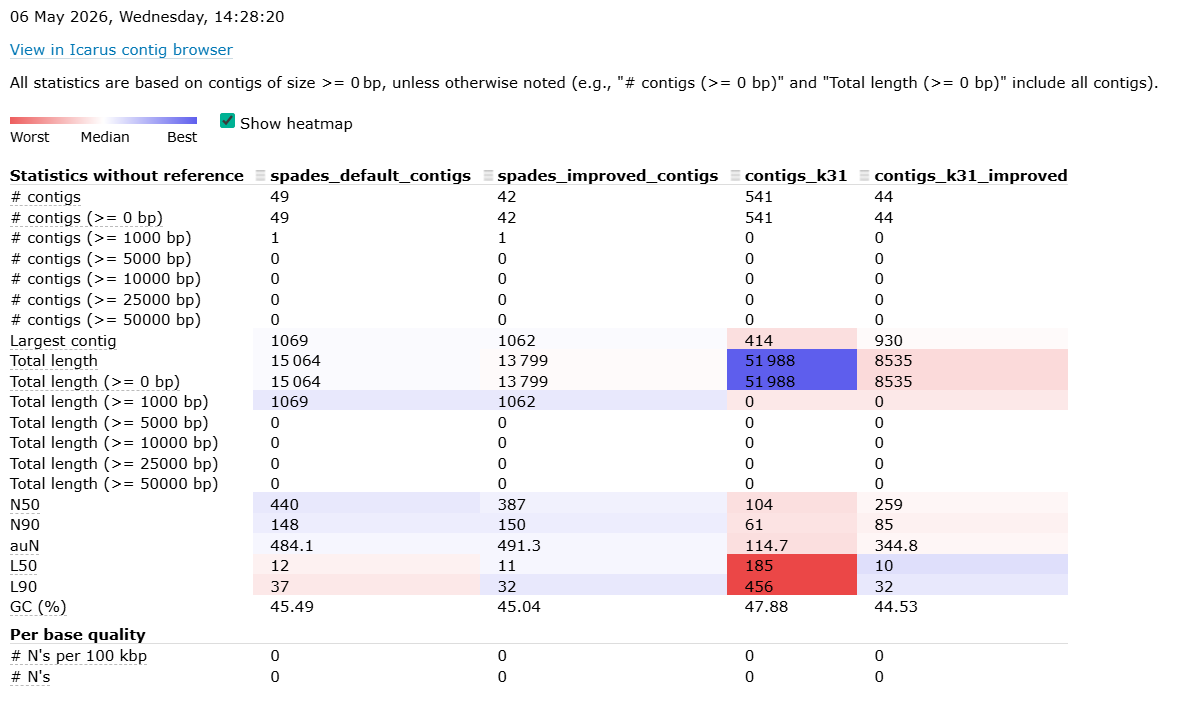

**Анализ таблицы**

- **SPAdes improved** (флаг `--isolate`) немного улучшил сборку по сравнению с default: число контигов уменьшилось с 49 до 42, N50 незначительно снизился (440→387), зато L50 улучшился (12→11). Общая длина сборки уменьшилась несущественно. Улучшение есть, но не драматическое.
- **Velvet improved** (параметр `-cov_cutoff 10`) дал значительный прогресс по сравнению с default k31: количество контигов сократилось с 541 до 44, N50 вырос с 104 до 259, а самый длинный контиг увеличился с 414 до 930. Однако общая длина сборки уменьшилась (51 988 → 8 535), что указывает на отсечение многих коротких ошибочных контигов.
- **Лучшей сборкой** по совокупности метрик остаётся **SPAdes improved**: у него наименьшее число контигов (42), хороший N50 (387) и самый длинный контиг (>1000). Velvet improved хоть и улучшился, но всё ещё уступает SPAdes: его максимальный контиг короче, N50 ниже, а GC% немного отличается, что может указывать на остаточные ошибки.

**Вывод:**

Улучшение Velvet с помощью `-cov_cutoff` оказалось эффективным и позволило сократить количество контигов в 12 раз, но SPAdes (особенно в режиме `--isolate`) остаётся более надёжным выбором для этих данных.

## **Вывод по заданию**

В ходе работы выполнена сборка бактериального генома с помощью Velvet и SPAdes, проведено сравнение и попытка улучшения.

- **Velvet** с разными k‑mer дал множество коротких контигов, ни один из которых не достигал 500 п.н. Качество сборок оказалось низким.
- **SPAdes** существенно превзошёл Velvet: количество контигов было в разы меньше, а показатели непрерывности (N50, длина максимального контига) — значительно выше. При стандартных настройках QUAST сборки Velvet вообще не отображались, прищлось менять минимум на 0.
- **Улучшение:** добавление флага `--isolate` к SPAdes немного сократило число контигов. У Velvet использование параметра `-cov_cutoff` резко уменьшило количество контигов и повысило N50, однако итоговые метрики всё равно уступали SPAdes.

 Для данных коротких прочтений SPAdes является более эффективным ассемблером, чем Velvet, как в стандартной, так и в улучшенной конфигурации. Причина — встроенные алгоритмы коррекции ошибок и адаптивный выбор k‑mer, критически важные при работе с реальными секвенированными данными.